In [1]:
import os
import sys
import anndata as ad
import numpy as np

import pandas as pd
import seaborn as sb
import metacells as mc

f_dir = os.path.dirname(os.path.abspath("__file__"))  
sys.path.append(os.path.abspath(os.path.join(f_dir, "..", "..", "utils")))

import constants
import utils

import tqdm 
import time

from statsmodels.stats.multitest import multipletests

from scipy.stats import wilcoxon
from scipy.stats import chi2
from scipy.stats import chisquare
from statsmodels.stats.multitest import multipletests
import principle_curve


%load_ext autoreload
%autoreload 2

sb.set_context("talk")
rng = np.random.default_rng(seed=42)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm


import multiprocessing as mp
from functools import partial
import tqdm
from scipy.cluster.hierarchy import leaves_list, linkage

import matplotlib.pyplot as plt
from matplotlib.patches import Patch


from matplotlib.colors import LinearSegmentedColormap

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


import math
import itertools as it
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from math import hypot


2025-12-21 11:26:25.479762: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-21 11:26:25.502968: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/ofirr/miniforge3/envs/amosbase8/lib/python3.12/site-packages/rpy2/robjects/packages_utils.py:127: UserWarning: Conflict when converting R symbols in the package "princurve" to Python symbols: 
-lines_principal_curve -> lines.principal_curve, lines.principal.curve
- plot_principal_curve -> plot.principal_curve, plot.principal.curve
- poi

In [ ]:
os.makedirs("./output", exist_ok=True)

In [2]:
cells_ad = ad.read_h5ad(constants.CELLS_PATH)
metacells_ad = ad.read_h5ad(constants.METACELLS_PATH)
cell_type_colors = pd.read_csv(constants.CELLS_TYPE_COLORS, index_col=0).to_dict()['color']

cells_with_clones_info = mc.ut.slice(cells_ad, obs=(cells_ad.obs.clone_id.notna() ) & (cells_ad.obs.clone_id != "nan"))

clone_counts = cells_ad.obs['clone_exp_id'].value_counts()
valid_clone_ids = clone_counts[clone_counts > 1].index
cells_with_clones = cells_with_clones_info[cells_with_clones_info.obs['clone_exp_id'].isin(valid_clone_ids)]
cells_with_clones = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.cell_type != "doublets")

media_list = ["I", "II", "III", "IV"]

## Figure 2A

In [3]:
cells_per_clone_sample_day_bin_condition_df = cells_with_clones.obs.groupby(["condition","sample_day_bin", "clone_exp_id"], observed=False).size().unstack(fill_value=0)

I
N=1512 clones


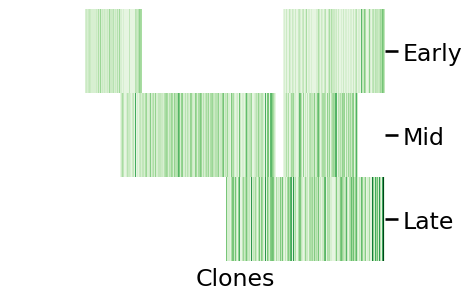

II
N=290 clones


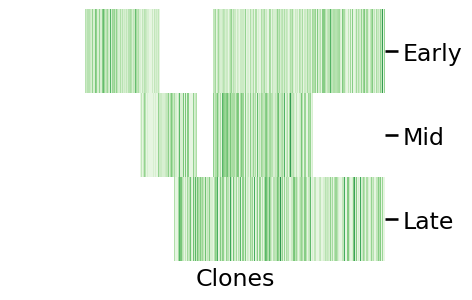

III
N=468 clones


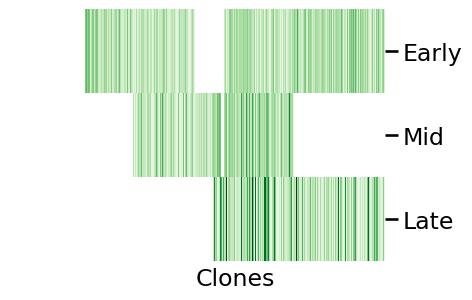

IV
N=208 clones


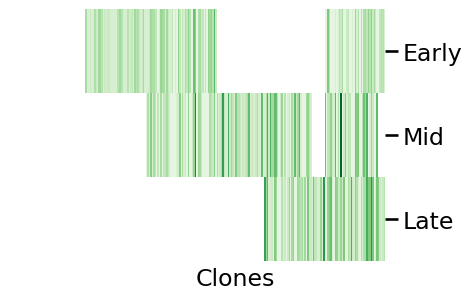

In [4]:
for condition in media_list:
    print(condition)
    condition_df = cells_per_clone_sample_day_bin_condition_df.loc[condition]
    condition_df = condition_df.loc[:, np.any(condition_df, axis=0)]
    condition_df = np.log2(condition_df + 1)
    condition_df = condition_df.loc[["Early", "Mid", "Late"], :]

    # desired order by presence pattern: only early, early+mid, early+late, only mid, mid+late, only late
    presence = (condition_df > 0).astype(int).loc[["Early", "Mid", "Late"]]
    order_key = {
        (1,0,0): 0,  # only early
        (1,1,0): 1,  # early mid
        (0,1,0): 2,  # mid
        (0,1,1): 3,  # mid late
        (0,0,1): 4,  # late
        (1,1,1): 5,  # early mid late
        (1,0,1): 6,  # early late               
    }
    col_order = presence.T.apply(lambda r: order_key.get(tuple(r.values.tolist()), 6), axis=1)
    sorted_cols = col_order.sort_values(kind="mergesort").index  # stable within groups
    condition_df = condition_df.loc[:, sorted_cols]

    # plot with fixed column order
    g = sb.clustermap(
        condition_df,
        mask=condition_df == 0,
        cmap="Greens",
        figsize=(5, 4),
        row_cluster=False,
        col_cluster=False,
        method="ward",
        xticklabels=False,
        yticklabels=True,
        cbar_pos=None,
        vmin=0, vmax=8.5,
    )
    g.ax_heatmap.set_xlabel("Clones", fontsize=17)
    g.ax_heatmap.set_ylabel("", fontsize=17)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=17, rotation=0)
    g.ax_col_dendrogram.set_visible(False)
    plt.savefig(os.path.join("./output", "2A_%s.pdf" %condition), dpi=1200, format="pdf", bbox_inches="tight")
    print("N=%d clones" % condition_df.shape[1])
    plt.show()
    plt.close()

/tmp/ipykernel_1274081/2056778661.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


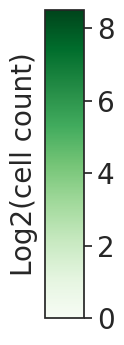

In [13]:
fig2, ax2 = plt.subplots(figsize=(0.5, 4))

norm = Normalize(vmin=0, vmax=8.5)
cmap = "Greens"
sm = ScalarMappable(norm=norm, cmap=cmap)

cbar = plt.colorbar(sm, cax=ax2)
cbar.ax.tick_params(labelsize=20)

cbar.set_label(f"Log2(cell count)", rotation=90, labelpad=5, fontsize=20)
cbar.ax.yaxis.set_label_position("left")

plt.tight_layout()
plt.savefig(os.path.join("./output", "2A_legend.pdf"), bbox_inches='tight', dpi=1200)
plt.show()

## Figure 2B

In [8]:
hue_norm = utils.Log2EpsNorm(epsilon=1/2, vmin=-1, vmax=4)  # adjust vmin based on your data range

In [9]:
for condition in cells_ad.obs.condition.unique():
    t = cells_ad[cells_ad.obs.condition == condition].obs.groupby("metacell_name", observed=True).size() / sum(cells_ad.obs.condition == condition) * 1000
    c = pd.Series(0, index=metacells_ad.obs_names, dtype=float)
    c.loc[t.index] = t.values
    mc.ut.set_o_data(metacells_ad, "condition_%s_new" %condition, c)

In [10]:
cmap = LinearSegmentedColormap.from_list(
        "darkgreen_grad",
        ["white",  "#74c476", "#00441b"] 
    )

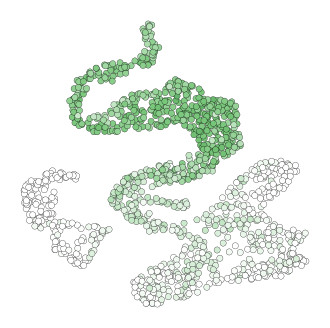

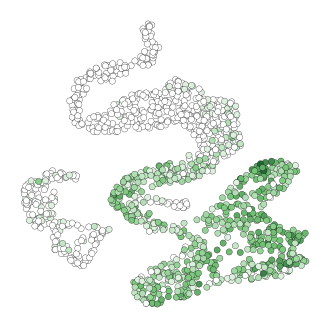

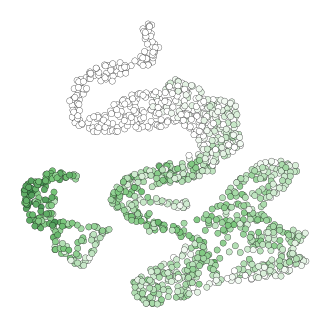

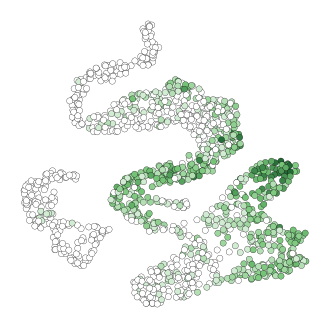

In [11]:
for condition in media_list:
    utils.plot_umap(metacells_ad, metadata_to_color="condition_%s_new" %condition, linewidth=0.2,
                          figsize=(4,4), s=20, palette=cmap, vlim=hue_norm, remove_legend=True,
                          output_path="./output/2B_%s.pdf" %condition)
    

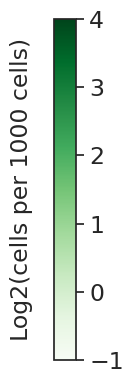

In [14]:
utils.plot_continuous_colorbar(
        cmap=cmap,
        label=f"Log2(cells per 1000 cells)",
        vmin=-1,  # adjust based on your data range
        vmax=4,
        output_path="./output/",
        filename="2A_colorbar",
    )

## Figure 2C, 2E, S3E

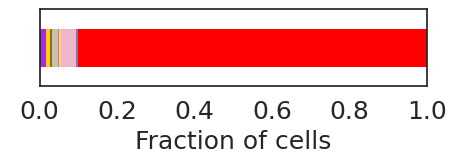

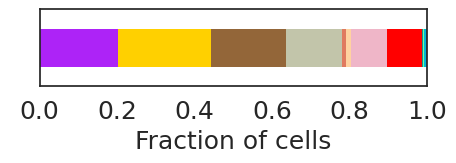

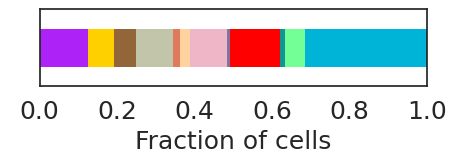

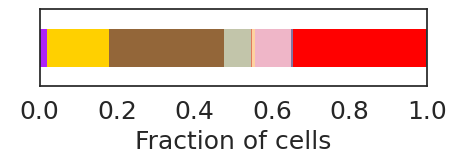

In [32]:
for condition in media_list:
    utils.plot_fractions_stacked_barplot(cells_with_clones.obs[cells_with_clones.obs.condition == condition], "condition", "top_level_cell_type", colors=cell_type_colors, 
                                    y_label=" ", x_label="Fraction of cells",
                                    x_order = [condition],
                                    y_order = cell_type_colors.keys(), remove_legend=True, figsize=(5,1), show_yticks=False,
                                    output_path="./output/2C_cells_%s.pdf" %condition
    )

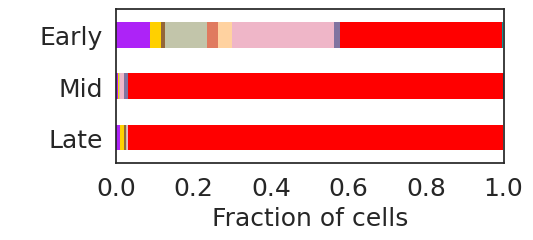

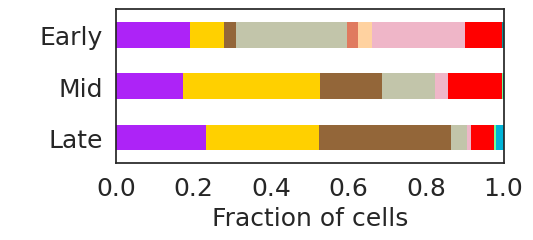

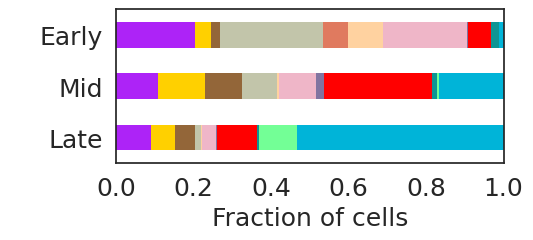

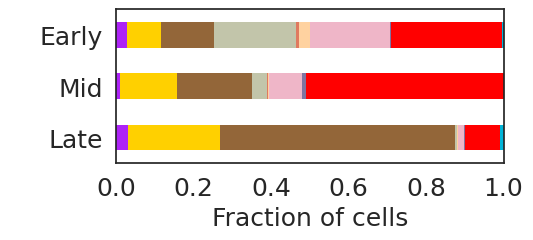

In [33]:
for condition in media_list:
    utils.plot_fractions_stacked_barplot(cells_with_clones.obs[cells_with_clones.obs.condition == condition], 
                                                        "sample_day_bin", "top_level_cell_type", colors=cell_type_colors, 
                                                        y_label=" ", x_label="Fraction of cells",
                                                        x_order = ["Late","Mid", "Early"],
                                                        y_order = cell_type_colors.keys(), remove_legend=True, figsize=(5,2), show_yticks=True, observed=False,
                                                        output_path=os.path.join("./output", "S3E_cells_%s_per_time" %condition)
            )

/tmp/ipykernel_931703/1861528309.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/1861528309.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/1861528309.py:25: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



I


/tmp/ipykernel_931703/1861528309.py:49: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



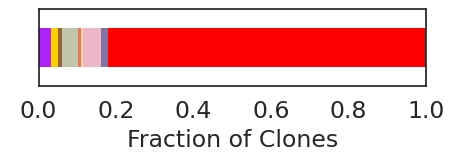

/tmp/ipykernel_931703/1861528309.py:49: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



II


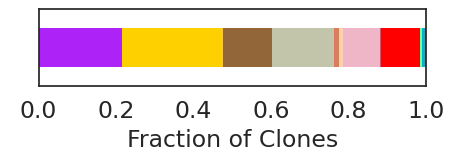

III


/tmp/ipykernel_931703/1861528309.py:49: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



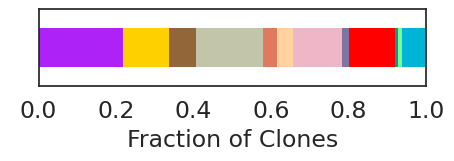

IV


/tmp/ipykernel_931703/1861528309.py:49: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



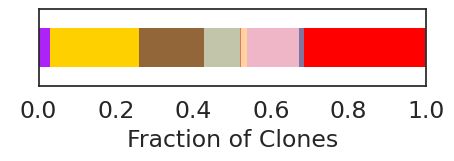

In [34]:
df = cells_with_clones.obs.copy()

# Step 1: compute per-clone cell type distributions (fractions)
clone_type_fraction = (
    df.groupby(['clone_exp_id', 'top_level_cell_type'], observed=True)
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .reset_index(name='vote')
)

# Step 2: add condition info
clone_condition = df[['clone_exp_id', 'condition']].drop_duplicates()
clone_type_fraction = clone_type_fraction.merge(clone_condition, on='clone_exp_id')

# Step 3: aggregate votes per condition and cell type
condition_votes = (
    clone_type_fraction
    .groupby(['condition', 'top_level_cell_type'])['vote']
    .sum()
    .reset_index()
)

# Step 4: normalize within each condition
condition_votes['fraction'] = condition_votes.groupby('condition')['vote'].transform(lambda x: x / x.sum())

for condition in media_list:
    print(condition)
    plot_df = condition_votes.pivot(index='condition', columns='top_level_cell_type', values='fraction').fillna(0)
    plot_df = plot_df.loc[[condition],]
    plot_df = plot_df.loc[:,[i for i in cell_type_colors.keys() if i in plot_df.columns]]


    # Optional: match the color order to your palette
    # Ensure your palette is a dict: {'Ery': 'red', 'Mast': 'blue', ...}
    colors = [cell_type_colors.get(col, 'gray') for col in plot_df.columns]

    # Plot
    ax = plot_df.plot(kind='barh', stacked=True, figsize=(5,1), color=colors ,edgecolor="none",linewidth=0)

    # Style
    plt.xlabel("Fraction of Clones", fontsize=17)
    plt.ylabel(" ", fontsize=17)
    plt.xticks(np.arange(0,1.2,0.2), fontsize=17)
    plt.yticks(fontsize=17)
    plt.yticks([])
    plt.xlim(0,1)
    plt.legend().remove()
    plt.tight_layout()
    plt.savefig(os.path.join("./output", "2C_clones_%s.pdf" % condition), dpi=1200, format="pdf", bbox_inches="tight")    
    plt.show()

/tmp/ipykernel_931703/3197026256.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/3197026256.py:29: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



I


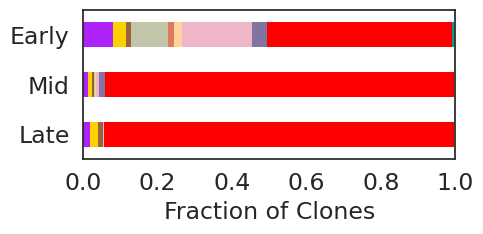

II


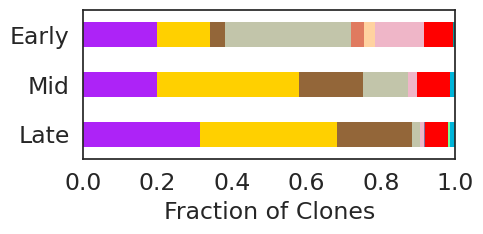

III


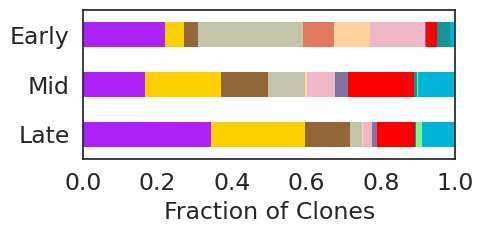

IV


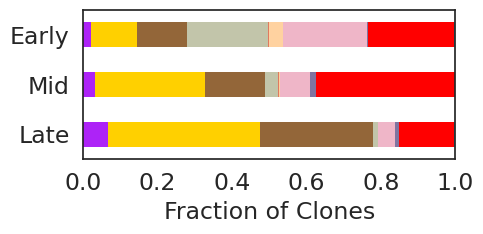

In [35]:
df = cells_ad.obs.copy()

# 1) per-clone×bin cell-type fractions
clone_type_fraction = (
    df.groupby(["clone_exp_id", "sample_day_bin", "top_level_cell_type"], observed=True)
      .size()
      .groupby(level=["clone_exp_id", "sample_day_bin"])
      .transform(lambda x: x / x.sum())
      .reset_index(name="vote")
)

# 2) add condition per clone×bin
clone_cond_bin = df[["clone_exp_id", "sample_day_bin", "condition"]].drop_duplicates()
clone_type_fraction = clone_type_fraction.merge(
    clone_cond_bin, on=["clone_exp_id", "sample_day_bin"], how="left"
)

# 3) aggregate votes per condition×bin×cell-type
cond_bin_votes = (
    clone_type_fraction
      .groupby(["condition", "sample_day_bin", "top_level_cell_type"], observed=True)["vote"]
      .sum()
      .reset_index()
)

# 4) normalize within each condition×bin
cond_bin_votes["fraction"] = (
    cond_bin_votes
      .groupby(["condition", "sample_day_bin"])["vote"]
      .transform(lambda x: x / x.sum())
)

# 5) plot one stacked bar per (condition, bin)

expected_bins = ["Late", "Mid", "Early", ]

for condition in media_list:
    print(condition)
    plot_df = (
        cond_bin_votes.query("condition == @condition")
        .pivot(index="sample_day_bin", columns="top_level_cell_type", values="fraction")
        .fillna(0)
    )

    # reorder columns to match palette
    cols = [k for k in cell_type_colors.keys() if k in plot_df.columns]
    plot_df = plot_df.reindex(columns=cols)

    # ensure all expected bins exist (insert zero rows if missing)
    plot_df = plot_df.reindex(expected_bins).fillna(0)

    colors = [cell_type_colors.get(col, "gray") for col in plot_df.columns]

    ax = plot_df.plot(kind="barh", stacked=True, figsize=(5, 2.5), color=colors,edgecolor="none",linewidth=0)

    plt.xlabel("Fraction of Clones", fontsize=17)
    plt.ylabel("", fontsize=17)
    plt.xticks(np.arange(0, 1.2, 0.2), fontsize=17)
    plt.yticks(fontsize=17)
    plt.xlim(0, 1)
    plt.legend().remove()
    plt.tight_layout()

    plt.savefig(os.path.join("./output","2E_clones_%s_per_time.pdf" %condition),dpi=1200, format="pdf", bbox_inches="tight")
    plt.show()

## Figure 2D

In [36]:
mature_cell_types = ["MK", "Ery","Mast", 'Basophils', 'Eosinophil', 'Monocyte', 'Neutrophils']


def plot_clones_by_colors(cells_with_clones, media_name, figsize=(25, 15), fontsize=35, output_path=None):
    columns = [i for i in cell_type_colors.keys() if i in cells_with_clones.obs.cell_type.unique()]
    
    clones_top_cell_types = cells_with_clones.obs.groupby(["clone_exp_id", "top_level_cell_type"], observed=True).size().unstack(fill_value= 0)
    mature_cell_type_appera = clones_top_cell_types.columns.intersection(mature_cell_types)
    multi_potent_clones = np.sum(clones_top_cell_types[mature_cell_type_appera] > 0,axis=1) > 1
    clones_cell_types_distribution_c = cells_with_clones.obs.groupby(["clone_exp_id", "cell_type"], observed=True).cell_type.count().unstack().fillna(0)
    
    clones_cell_types_distribution = pd.DataFrame(0, index=clones_cell_types_distribution_c.index, columns=columns)
    for i in columns:
        if i in clones_cell_types_distribution_c.columns:
            clones_cell_types_distribution[i] = clones_cell_types_distribution_c[i]
    
    clones_cell_types_distribution = clones_cell_types_distribution.astype(bool)

    clones_cell_types_distribution = utils.order_by_slanter(clones_cell_types_distribution, cluster_cols=False)

    clones_cell_types_distribution_for_plot = clones_cell_types_distribution.astype(bool) * np.array(range(1, clones_cell_types_distribution.shape[1] + 1))
    
    cmap = mcolors.ListedColormap(["#f6f7f7"] + [cell_type_colors[i] for i in clones_cell_types_distribution_for_plot.columns])

    row_colors = pd.Series(
    ["black" if multi_potent_clones[i] else "white" for i in clones_cell_types_distribution.index],
    index=clones_cell_types_distribution.index,
    name="Multipotent"  # ← this will be used as the title automatically
)
    print("Multipotent percent: %.2f" % ((row_colors == "black").sum() / row_colors.shape[0] * 100))
    
    g = sb.clustermap(clones_cell_types_distribution_for_plot, figsize=figsize, col_cluster=False, row_cluster=False, cmap=cmap, method="ward", 
                      row_colors=pd.DataFrame(row_colors)
                      )
    
    # remove colorbar
    g.cax.set_visible(False)
    
    # remove y labels
    g.ax_heatmap.set_yticks([])  # Remove the ticks
    g.ax_heatmap.set_yticklabels([])  # Remove the labels
    
    # g.ax_heatmap.set_title(media_name, fontsize=fontsize, pad=20)
    g.ax_heatmap.set_ylabel("Clones", fontsize=fontsize)
    g.ax_heatmap.set_xlabel("Cell type", fontsize=fontsize)

    # remove dendrogram
    g.ax_row_dendrogram.set_visible(False)

    # move xticks to top but in 90 degree
    g.ax_heatmap.xaxis.tick_top()
    _ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=fontsize)
    label = g.ax_row_colors.get_ylabel()
    g.ax_row_colors.set_ylabel(None)
    g.ax_row_colors.set_title(label, y=1.18, loc="center")

    label = getattr(row_colors, "name", "Multipotent")

    # Get the row-colors axis bbox in figure coordinates
    label = getattr(row_colors, "name", "Multipotent")

    # --- 1. keep the small color-axis ticks ---
    g.ax_row_colors.tick_params(left=False, labelleft=False, right=False, labelright=False,
                                bottom=False, labelbottom=False, top=True, labeltop=False)

    # --- 2. add title above using figure coords ---
    bbox = g.ax_row_colors.get_position()
    x = bbox.x0 + bbox.width / 2 -0.005
    y = bbox.y1 -0.03 # tweak upward spacing
    g.fig.text(
        x, y, label,
        ha="center", va="bottom",
        rotation=90,           # change to 0 for horizontal
        fontsize=fontsize,
        transform=g.fig.transFigure
    )

    # --- 3. optional small layout relaxation ---
    g.fig.subplots_adjust(top=0.93)


    if output_path:
        plt.savefig(os.path.join(output_path,'2D_%s.pdf' %media_name), bbox_inches='tight', dpi=1000)
        plt.show()
        plt.close()

I
Multipotent percent: 7.08


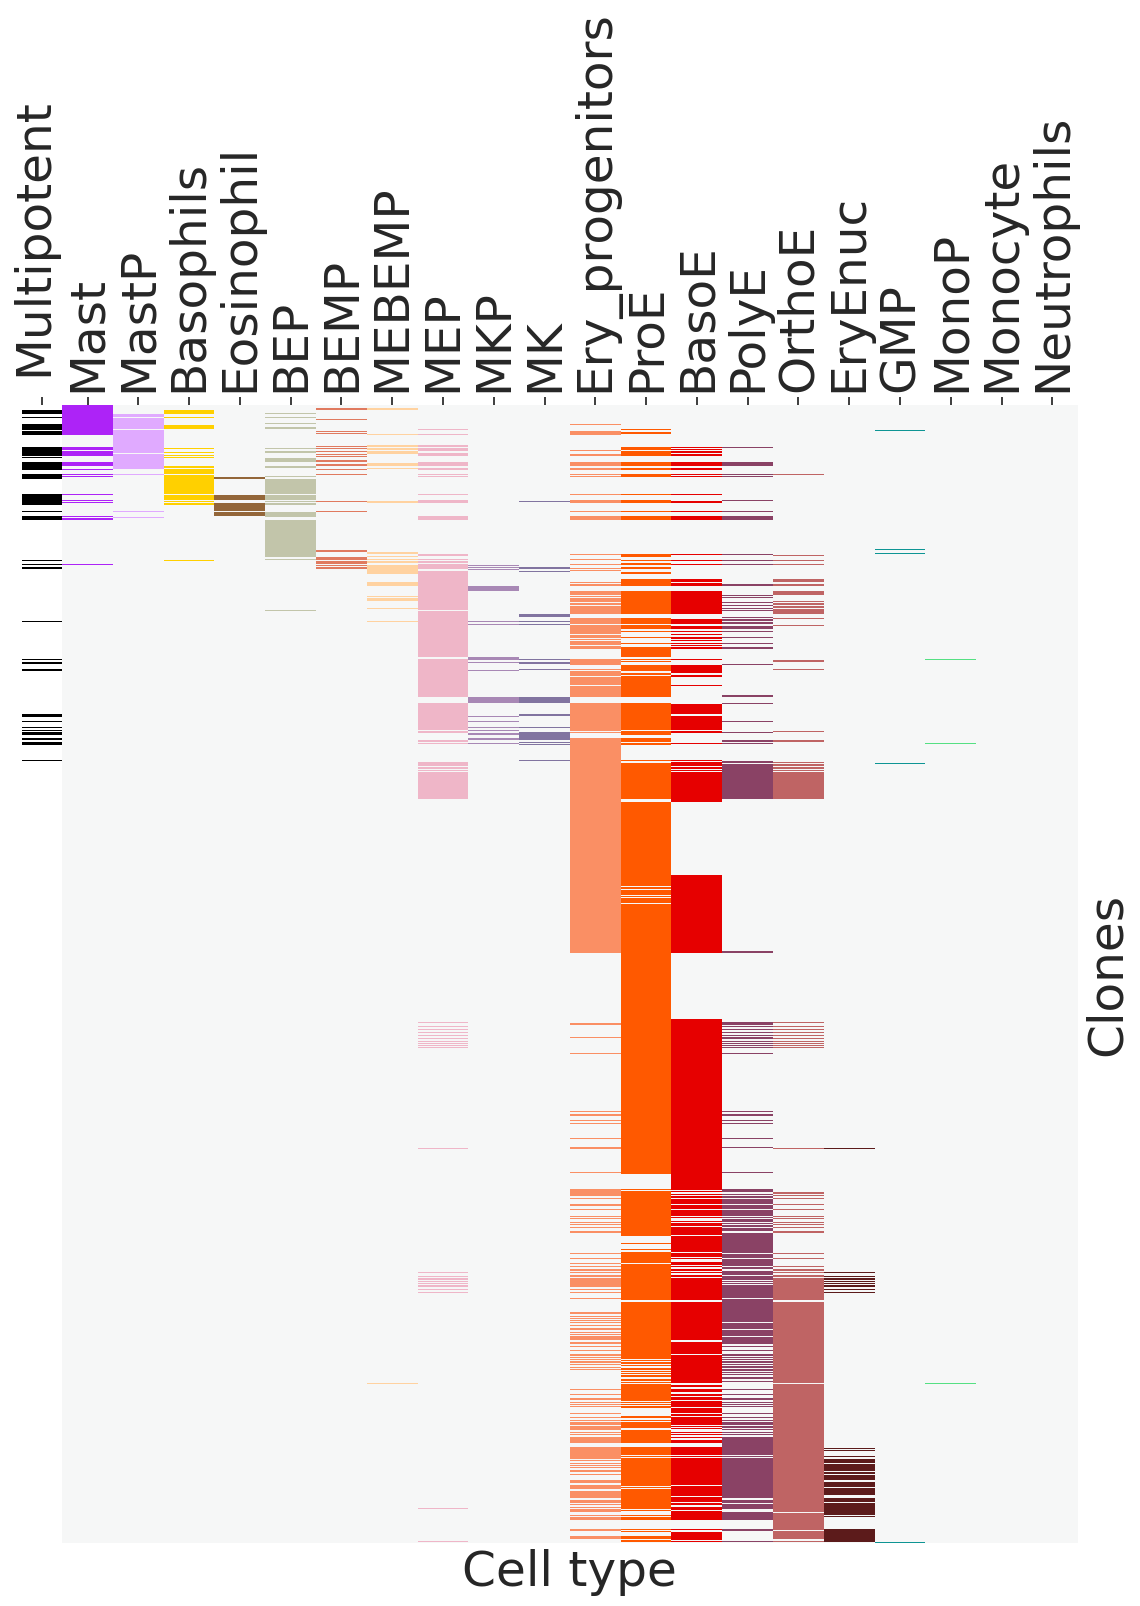

II
Multipotent percent: 40.00


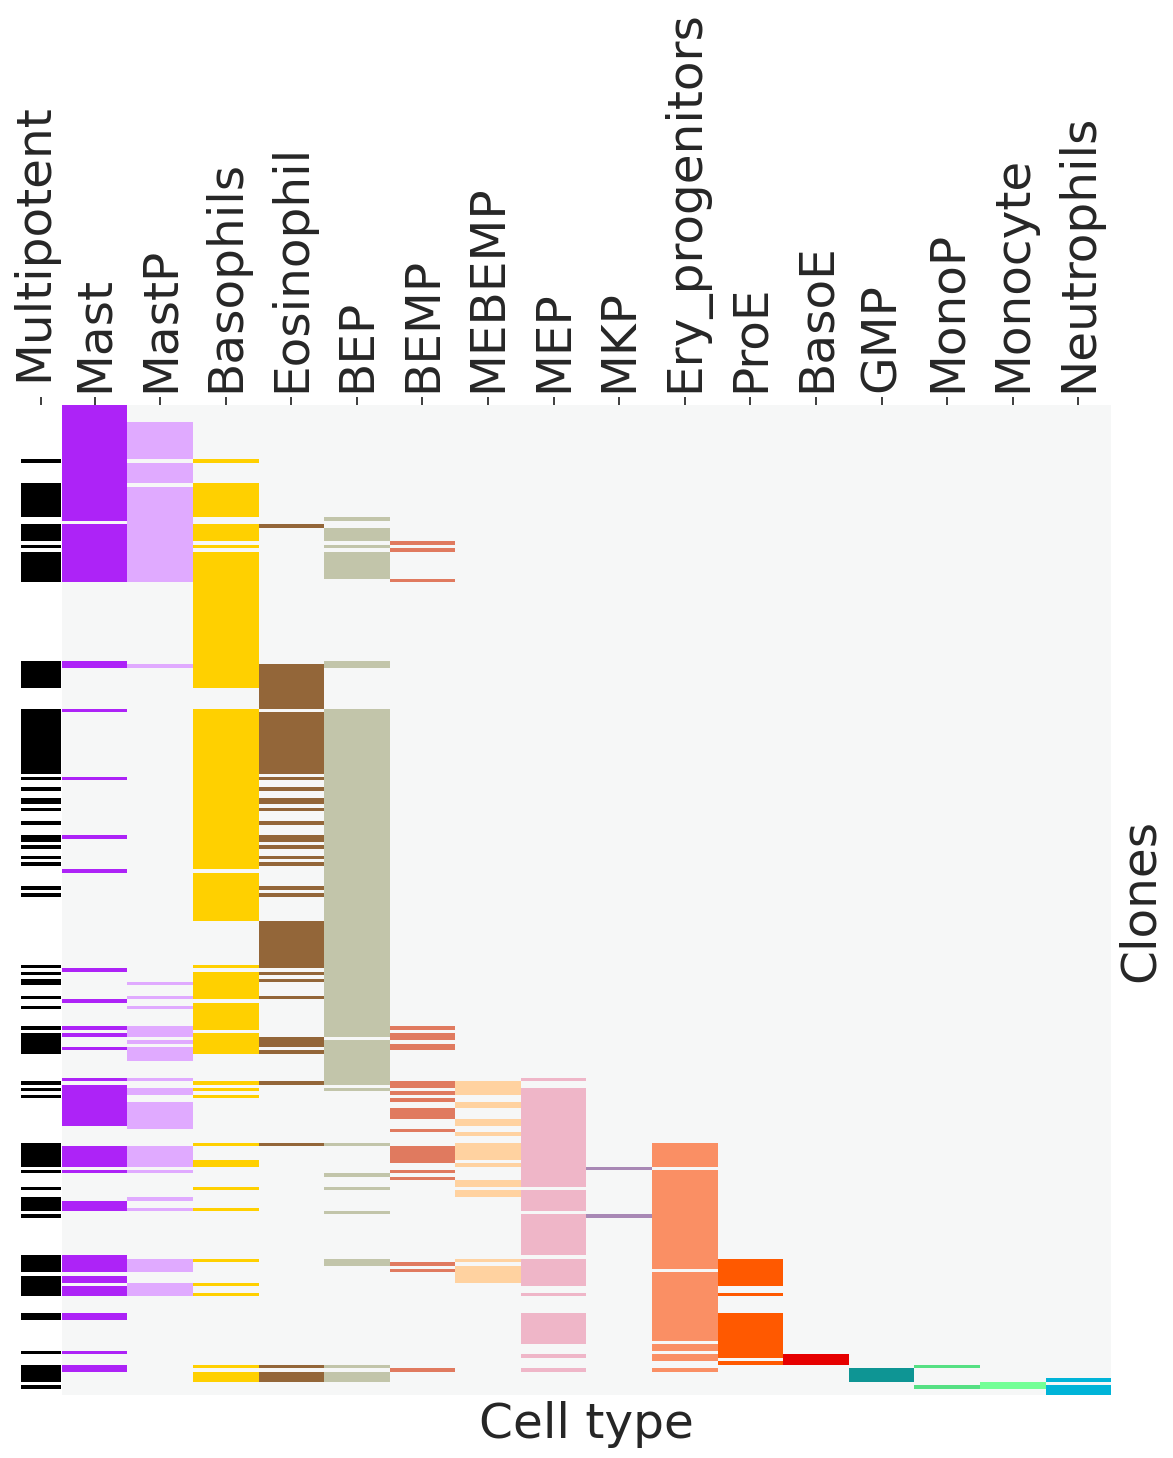

III
Multipotent percent: 48.08


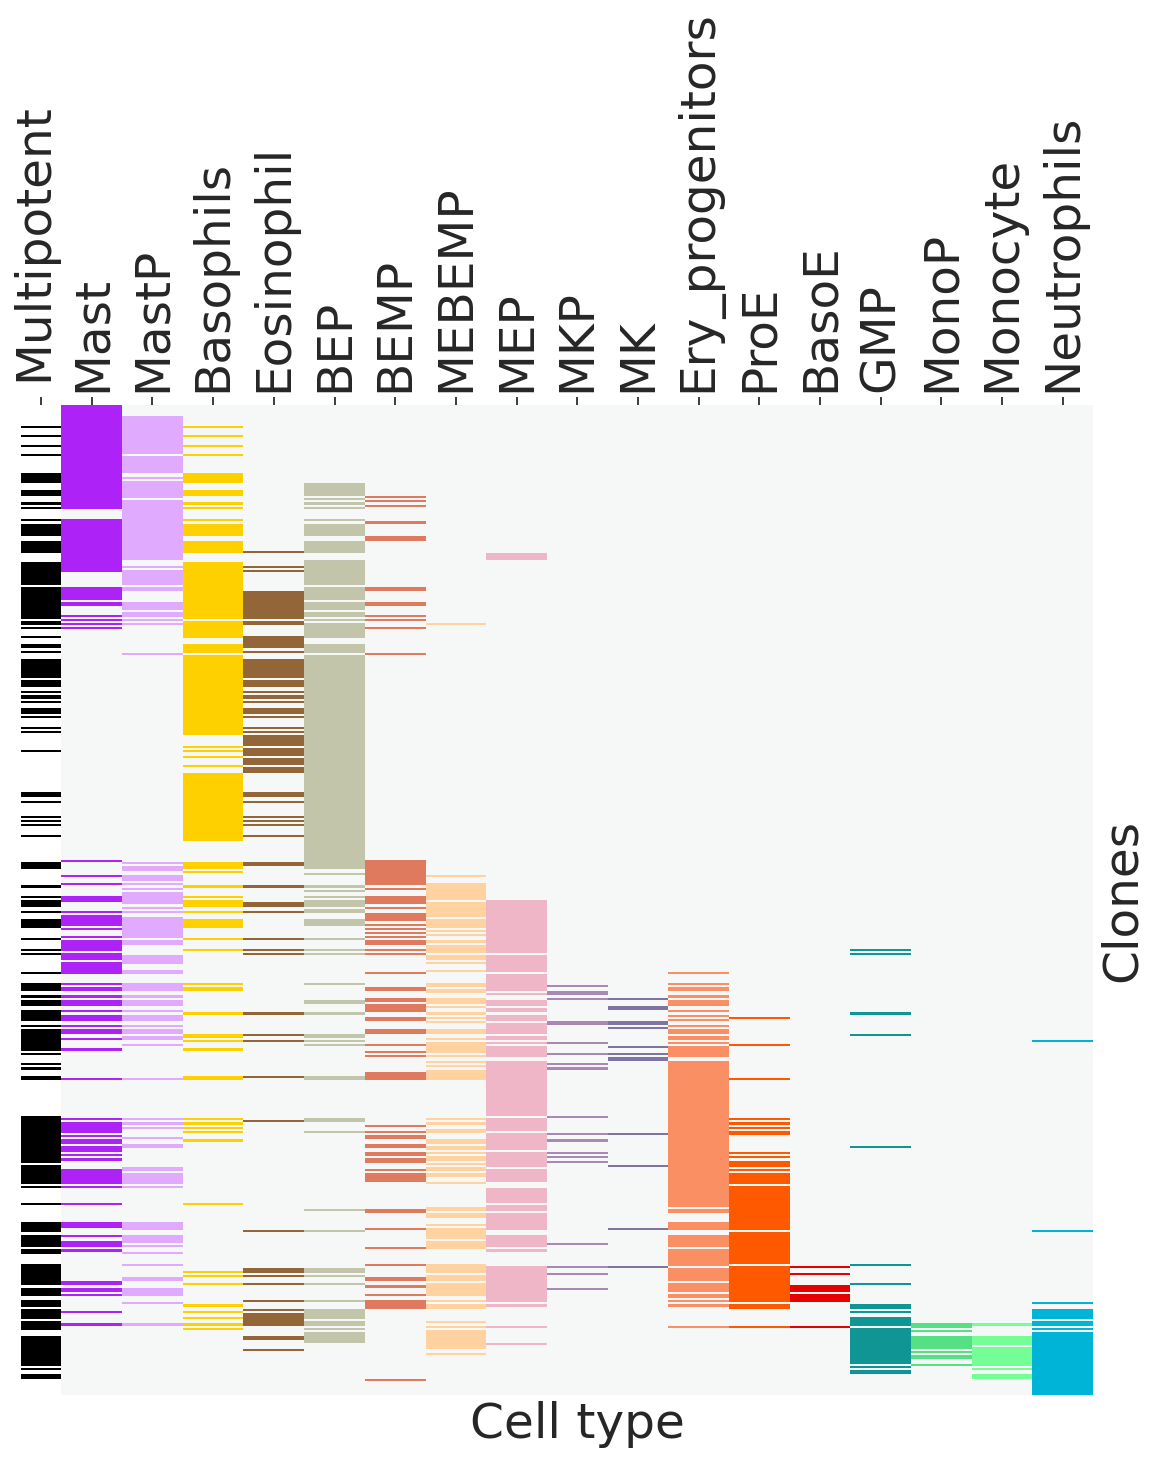

IV
Multipotent percent: 35.10


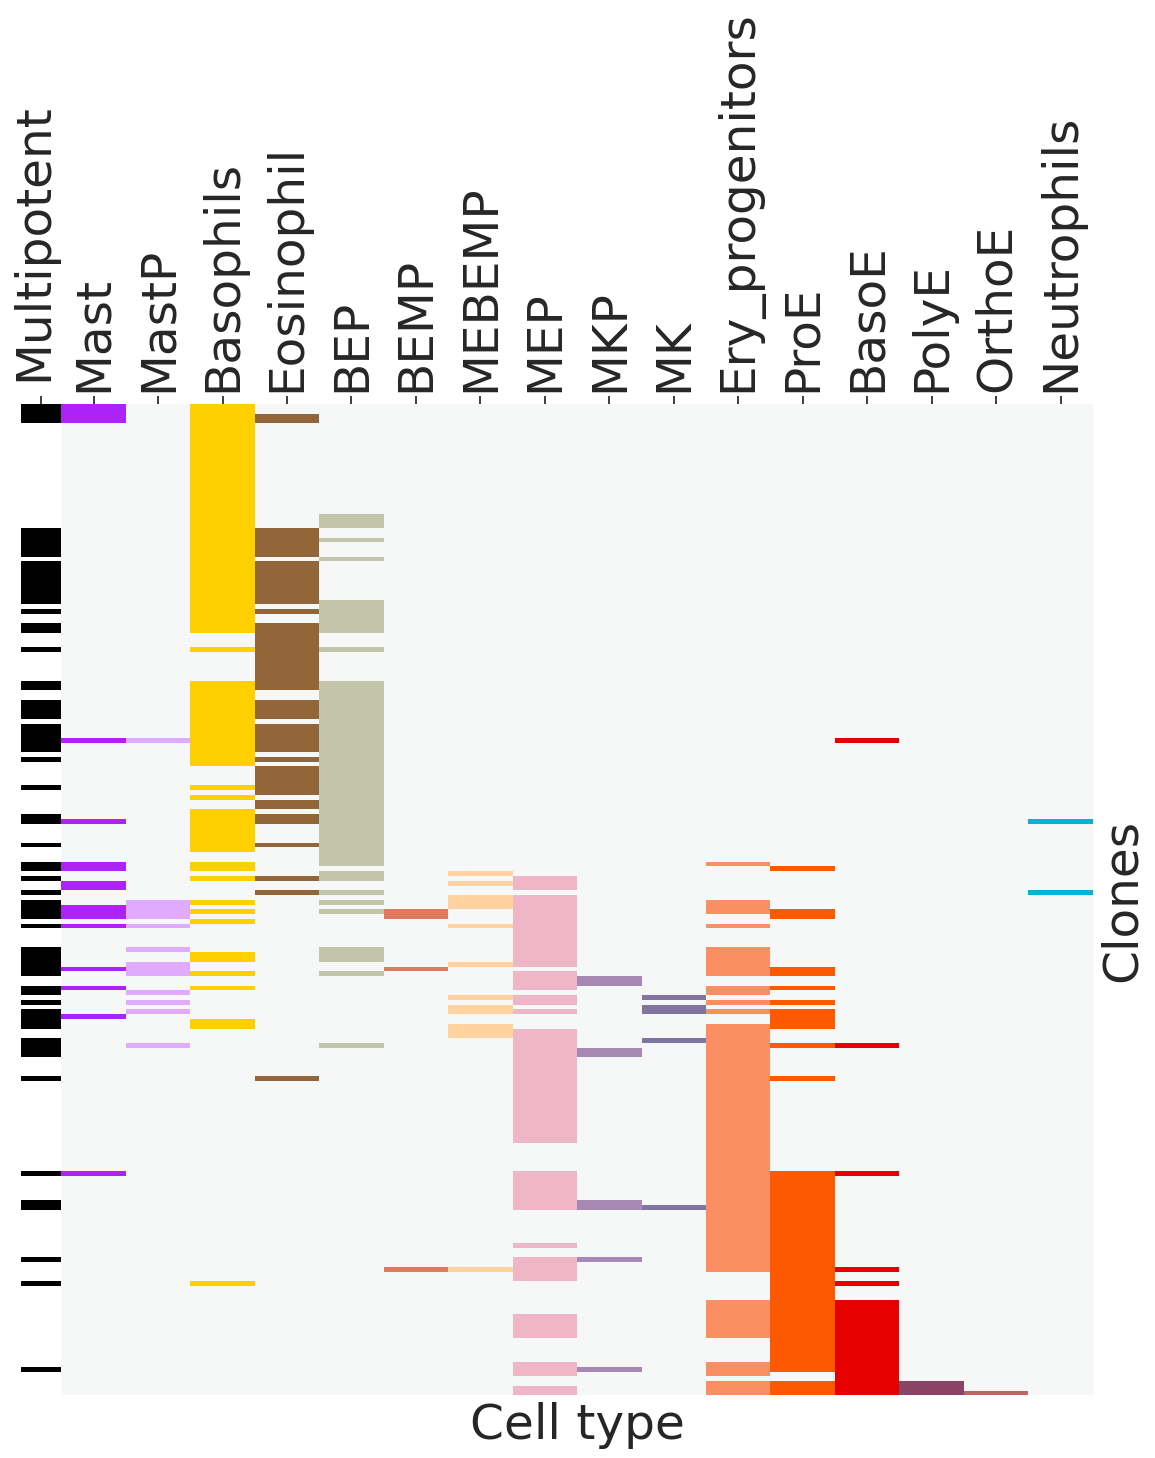

In [37]:
condition_df = {}
for condition_name in media_list:
    print(condition_name)
    if condition_name == "I":
        f = (17,17)
    else:
        f = (15,15)
    plot_clones_by_colors(mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.condition == condition_name), condition_name, figsize=f, output_path="./output")

In [38]:
def distinct_two_types_stats_by_condition(df):
    import pandas as pd

    needed = ['MEBEMP','MEP','Ery','MK','BEMP','Basophils','Eosinophil','Mast',
              'GMP','Monocyte','Neutrophils']
    for c in needed:
        if c not in df.columns:
            df[c] = 0

    pres = (df[needed] > 0)

    # MEP/BEMP branches and umbrellas
    has_mep_branch = pres['MEP'] | pres[['Ery','MK']].any(axis=1)
    has_bemp_child = pres[['Basophils','Eosinophil','Mast']].any(axis=1)
    has_bemp_branch = pres['BEMP'] | has_bemp_child
    has_mebemp_umbrella = pres['MEBEMP'] | has_mep_branch | has_bemp_branch

    # GMP umbrella
    has_monocyte = pres['Monocyte']
    has_neutro = pres['Neutrophils']
    has_gmp_umbrella = pres['GMP'] | has_monocyte | has_neutro

    # Internal distinctness
    mep_internal = pres['Ery'] & pres['MK']
    bemp_internal = pres[['Basophils','Eosinophil','Mast']].sum(axis=1) >= 2
    gmp_internal = has_monocyte & has_neutro

    # Cross-family distinctness
    mep_vs_bemp = has_mep_branch & has_bemp_branch
    gmp_vs_mebemp = has_gmp_umbrella & has_mebemp_umbrella

    has_two_distinct = mep_internal | bemp_internal | gmp_internal | mep_vs_bemp | gmp_vs_mebemp
    has_two_distinct.name = 'has_two_distinct'

    # Aggregate per condition (assumes level 0 is condition_merged)
    grp = has_two_distinct.groupby(level=0, observed=True)
    n = grp.sum().rename('n_clones_distinct')
    total = grp.size().rename('n_clones_total')
    pct = (n / total * 100).rename('percent_clones_with_≥2_distinct_types')

    return pd.concat([n, total, pct], axis=1).sort_index(), has_two_distinct

cell_types_per_condition_clone_exp_id = cells_with_clones.obs.groupby(["condition",  "clone_exp_id", "top_level_cell_type"], observed=True).size().unstack() > 0

for condition in ["I","II","III","IV"]:
    table, per_clone_flag = distinct_two_types_stats_by_condition(cell_types_per_condition_clone_exp_id.loc[condition])
    print("%s : %.2f" % (condition, per_clone_flag.sum() / per_clone_flag.shape[0]))

I : 0.08
II : 0.44
III : 0.57
IV : 0.37


## Figure 2F

In [39]:
def chord_from_clone_df(
    df: pd.DataFrame,
    node_colors: dict,
    presence_thresh: float = 0,
    min_frac: float = 0.0,
    edge_scale: float = 30.0,
    min_edge_width: float = 2.0,
    allow_self_loops: bool = False,   # include self counts (>=2 cells in a clone → +1)
    show_node_names: bool = True,
    repel_edge_labels: bool = True,
    figsize=(7, 7),
    output_path: str | None = None,
):
    """Chord diagram with undirected edges, symmetric colors, and optional label repulsion."""
    cols = list(df.columns)
    total_clones = len(df)

    # 1) co-occurrence counts (undirected) with corrected self-loop logic
    pair_counts = {}
    for row_vals in df[cols].itertuples(index=False, name=None):
        counts = dict(zip(cols, row_vals))

        # types present in this clone (strictly > presence_thresh)
        active = [c for c, v in counts.items() if v > presence_thresh]

        # cross-type pairs: +1 per clone if both types present
        for a, b in it.combinations(sorted(active), 2):
            key = (a, b)
            pair_counts[key] = pair_counts.get(key, 0) + 1

        # self-loops: only if clone is exclusively one type AND that type has >=2 cells
        if allow_self_loops and len(active) == 1:
            a = active[0]
            if counts[a] > 1:  # this > and not >- actually make it havee at least 2 cells in terminal
                key = (a, a)
                pair_counts[key] = pair_counts.get(key, 0) + 1

    if not pair_counts:
        print("No co-occurrences found.")
        return pd.DataFrame(columns=["a", "b", "n", "frac"]), cols

    ordered_nodes = cols[:]  # preserve column order

    # self-loop counts for node labels
    self_counts = {c: pair_counts.get((c, c), 0) if allow_self_loops else 0 for c in ordered_nodes}

    # geometry
    N = len(ordered_nodes)
    angles = {c: 2 * math.pi * i / N for i, c in enumerate(ordered_nodes)}
    R = 1.0
    node_xy = {c: (R * math.cos(angles[c]), R * math.sin(angles[c])) for c in ordered_nodes}

    # edges table (exclude self-loops from drawing, but keep counts for labeling nodes)
    edges = []
    for (a, b), n in pair_counts.items():
        if a == b:
            continue
        frac = n / total_clones
        if frac >= min_frac:
            edges.append({"a": a, "b": b, "n": int(n), "frac": frac, "percent": frac * 100.0})
    edges = pd.DataFrame(edges).sort_values("frac", ascending=False)

    # helpers
    def _quad_bezier_points(p0, p1, c=(0.0, 0.0), n=240):
        ts = np.linspace(0, 1, n)
        x = (1 - ts) ** 2 * p0[0] + 2 * (1 - ts) * ts * c[0] + ts ** 2 * p1[0]
        y = (1 - ts) ** 2 * p0[1] + 2 * (1 - ts) * ts * c[1] + ts ** 2 * p1[1]
        return x, y

    placed_labels = []

    def _place_label(ax, x_curve, y_curve, text, color,
                     k0=0.02, k_step=0.01, min_dist=0.08, tries=10,
                     t_candidates=(0.35, 0.5, 0.65)):
        for t in t_candidates:
            i = int(t * (len(x_curve) - 1))
            dx = x_curve[min(i + 1, len(x_curve) - 1)] - x_curve[max(i - 1, 0)]
            dy = y_curve[min(i + 1, len(y_curve) - 1)] - y_curve[max(i - 1, 0)]
            nlen = (dx * dx + dy * dy) ** 0.5 or 1.0
            nx, ny = -dy / nlen, dx / nlen
            k = k0
            for _ in range(tries):
                lx, ly = x_curve[i] + k * nx, y_curve[i] + k * ny
                if all(hypot(lx - xp, ly - yp) >= min_dist for xp, yp in placed_labels):
                    ax.text(
                        lx, ly, text,
                        ha="center", va="center", fontsize=14, color="white",
                        bbox=dict(facecolor=color, edgecolor="none",
                                  boxstyle="round,pad=0.18", alpha=0.95),
                        path_effects=[pe.withStroke(linewidth=1.5, foreground="black", alpha=0.5)],
                        zorder=4,
                    )
                    placed_labels.append((lx, ly))
                    return True
                k += k_step
        return False

    # draw
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"aspect": "equal"})
    ax.set_axis_off()
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)

    # nodes
    for c in ordered_nodes:
        x, y = node_xy[c]
        col = node_colors.get(c, "gray")
        ax.scatter([x], [y], s=250, color=col, edgecolor="none", zorder=3)

        if show_node_names:
            label = f"{c} ({self_counts[c]})" if (allow_self_loops and self_counts[c] > 0) else c
            lab_r = 1.1
            lx, ly = lab_r * math.cos(angles[c]), lab_r * math.sin(angles[c])
            ha = "left" if lx >= 0 else "right"
            ax.text(lx, ly, label, ha=ha, va="center", fontsize=14, color=col)
        else:
            if allow_self_loops and self_counts[c] > 0:
                r_badge = 1.18
                bx, by = r_badge * math.cos(angles[c]), r_badge * math.sin(angles[c])
                ax.text(
                    bx, by, f"{self_counts[c]}",
                    ha="center", va="center", fontsize=14, color="white",
                    bbox=dict(facecolor=col, edgecolor="none",
                              boxstyle="round,pad=0.18", alpha=0.95),
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="black", alpha=0.5)],
                    zorder=4,
                )

    # edges with symmetric blended color
    edges = edges.sample(frac=1.0, random_state=0).reset_index(drop=True)  # mild shuffle

    for _, r in edges.iterrows():
        a, b, n, frac = r["a"], r["b"], int(r["n"]), r["frac"]
        p0, p1 = node_xy[a], node_xy[b]

        colA = np.array(mpl.colors.to_rgb(node_colors.get(a, "gray")))
        colB = np.array(mpl.colors.to_rgb(node_colors.get(b, "gray")))
        col = tuple(((colA + colB) / 2).clip(0, 1))

        lw = max(min_edge_width, edge_scale * frac)
        x_curve, y_curve = _quad_bezier_points(p0, p1, c=(0.0, 0.0))
        ax.plot(
            x_curve, y_curve, color=col, linewidth=lw,
            alpha=min(0.95, 0.4 + 0.6 * frac),
            solid_capstyle="round", zorder=2,
        )

        if n > 1:  # draw label only if count > 1
            if repel_edge_labels:
                _place_label(ax, x_curve, y_curve, str(n), col)
            else:
                mid = len(x_curve) // 2
                ax.text(
                    x_curve[mid], y_curve[mid], str(n),
                    ha="center", va="center", fontsize=14, color="white",
                    bbox=dict(facecolor=col, edgecolor="none",
                            boxstyle="round,pad=0.18", alpha=0.95),
                    path_effects=[pe.withStroke(linewidth=1.5, foreground="black", alpha=0.5)],
                    zorder=4,
                )

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path + ".pdf", dpi=1200, bbox_inches="tight", format ="pdf")
    plt.show()

    return edges, ordered_nodes

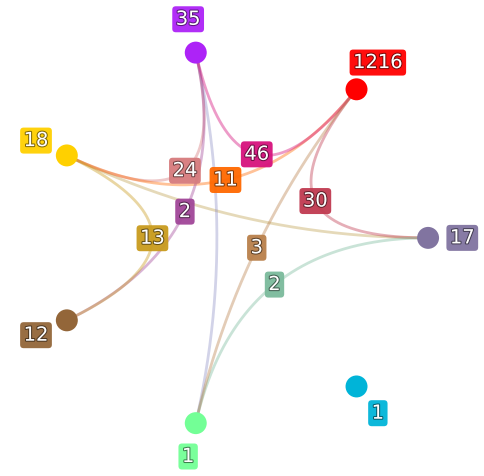

I
            a           b   n      frac   percent
0   Basophils        Mast  24  0.017058  1.705757
1   Basophils          MK   1  0.000711  0.071073
2   Basophils         Ery  11  0.007818  0.781805
3        Mast    Monocyte   1  0.000711  0.071073
4         Ery          MK  30  0.021322  2.132196
5  Eosinophil        Mast   2  0.001421  0.142146
6          MK    Monocyte   2  0.001421  0.142146
7   Basophils  Eosinophil  13  0.009240  0.923952
8         Ery        Mast  46  0.032694  3.269367
9         Ery    Monocyte   3  0.002132  0.213220


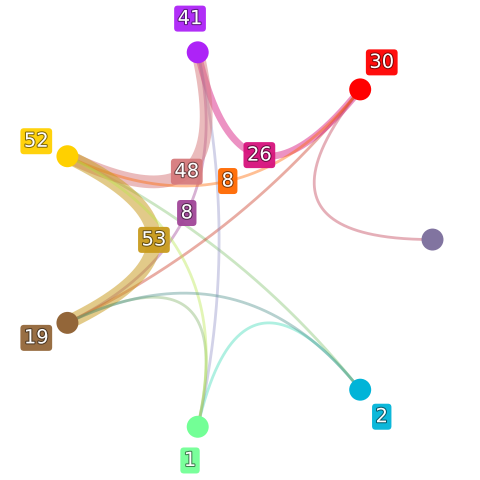

II
             a            b   n      frac    percent
0     Monocyte  Neutrophils   1  0.003831   0.383142
1    Basophils  Neutrophils   1  0.003831   0.383142
2   Eosinophil         Mast   8  0.030651   3.065134
3   Eosinophil          Ery   1  0.003831   0.383142
4          Ery         Mast  26  0.099617   9.961686
5         Mast     Monocyte   1  0.003831   0.383142
6    Basophils         Mast  48  0.183908  18.390805
7   Eosinophil     Monocyte   1  0.003831   0.383142
8          Ery           MK   1  0.003831   0.383142
9    Basophils          Ery   8  0.030651   3.065134
10   Basophils   Eosinophil  53  0.203065  20.306513
11   Basophils     Monocyte   1  0.003831   0.383142
12  Eosinophil  Neutrophils   1  0.003831   0.383142


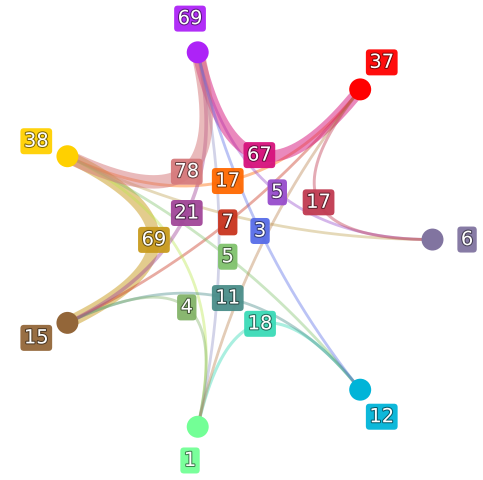

III
             a            b   n      frac    percent
0    Basophils   Eosinophil  69  0.171216  17.121588
1    Basophils          Ery  17  0.042184   4.218362
2   Eosinophil          Ery   7  0.017370   1.736973
3           MK         Mast   5  0.012407   1.240695
4    Basophils     Monocyte   1  0.002481   0.248139
5     Monocyte  Neutrophils  18  0.044665   4.466501
6          Ery         Mast  67  0.166253  16.625310
7         Mast     Monocyte   1  0.002481   0.248139
8    Basophils  Neutrophils   5  0.012407   1.240695
9   Eosinophil  Neutrophils  11  0.027295   2.729529
10   Basophils           MK   1  0.002481   0.248139
11  Eosinophil     Monocyte   4  0.009926   0.992556
12  Eosinophil         Mast  21  0.052109   5.210918
13   Basophils         Mast  78  0.193548  19.354839
14         Ery           MK  17  0.042184   4.218362
15         Ery     Monocyte   1  0.002481   0.248139
16        Mast  Neutrophils   3  0.007444   0.744417


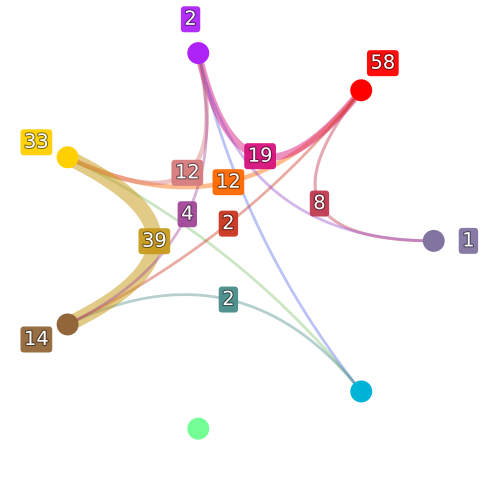

IV
             a            b   n      frac    percent
0          Ery           MK   8  0.044199   4.419890
1    Basophils  Neutrophils   1  0.005525   0.552486
2    Basophils          Ery  12  0.066298   6.629834
3         Mast  Neutrophils   1  0.005525   0.552486
4   Eosinophil  Neutrophils   2  0.011050   1.104972
5          Ery         Mast  19  0.104972  10.497238
6   Eosinophil          Ery   2  0.011050   1.104972
7           MK         Mast   1  0.005525   0.552486
8    Basophils         Mast  12  0.066298   6.629834
9    Basophils   Eosinophil  39  0.215470  21.546961
10  Eosinophil         Mast   4  0.022099   2.209945


In [40]:
for condition in media_list:

    df = cells_with_clones_info[cells_with_clones_info.obs.condition == condition].obs.groupby(["clone_exp_id", "top_level_cell_type"], observed=True).size().unstack(fill_value=0)
    for mature_cell_type in mature_cell_types:
        if mature_cell_type not in df.columns:
            df[mature_cell_type] = 0
    
    df = df[mature_cell_types]
    df = df[df.sum(axis=1) > 1]  # at least 2 cells in total
    print(condition)
    p = chord_from_clone_df(df, node_colors=cell_type_colors, allow_self_loops=True, figsize=(5,5), edge_scale=50, show_node_names=False, repel_edge_labels=False,
                        output_path= "./output/2F_pairs_%s" %condition)

    
    print(p[0])

## Figure S2D

In [41]:
import CloneObject

100%|██████████| 7/7 [00:00<00:00, 51.57it/s]


O12_I_7


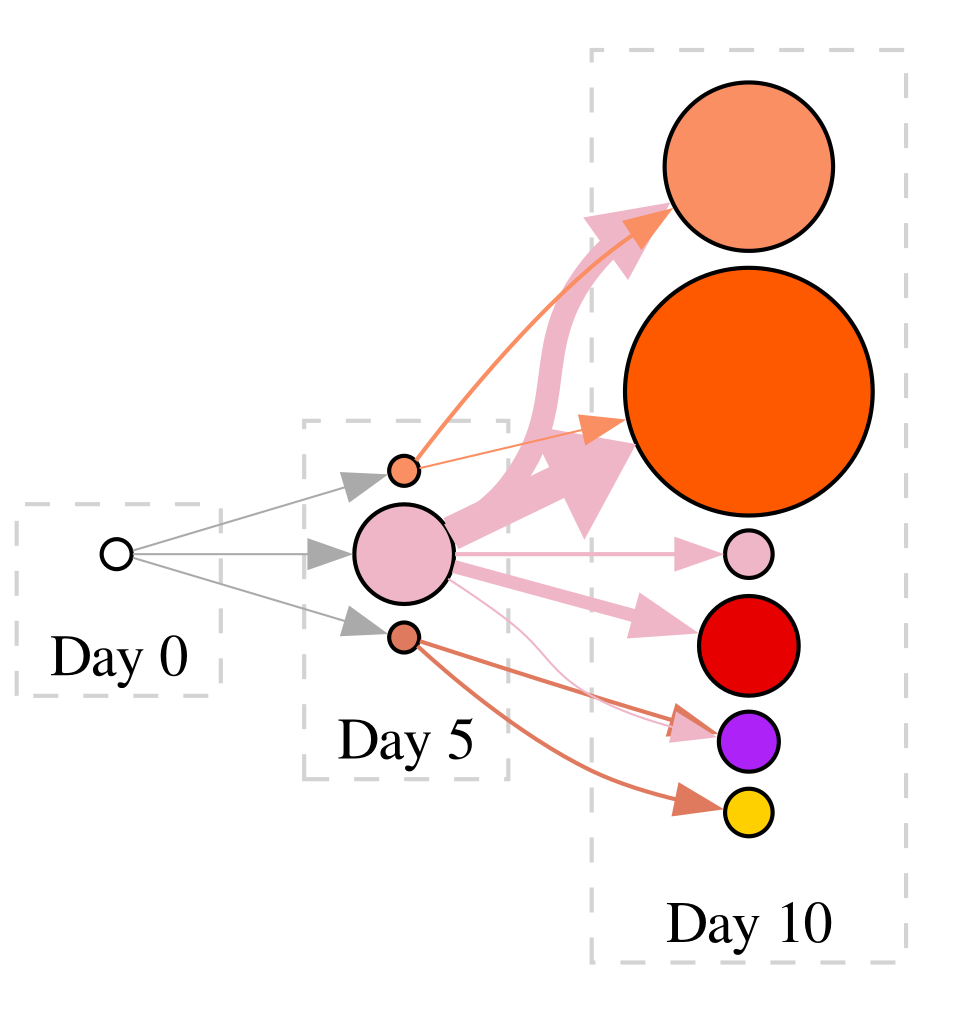

A9_I_7


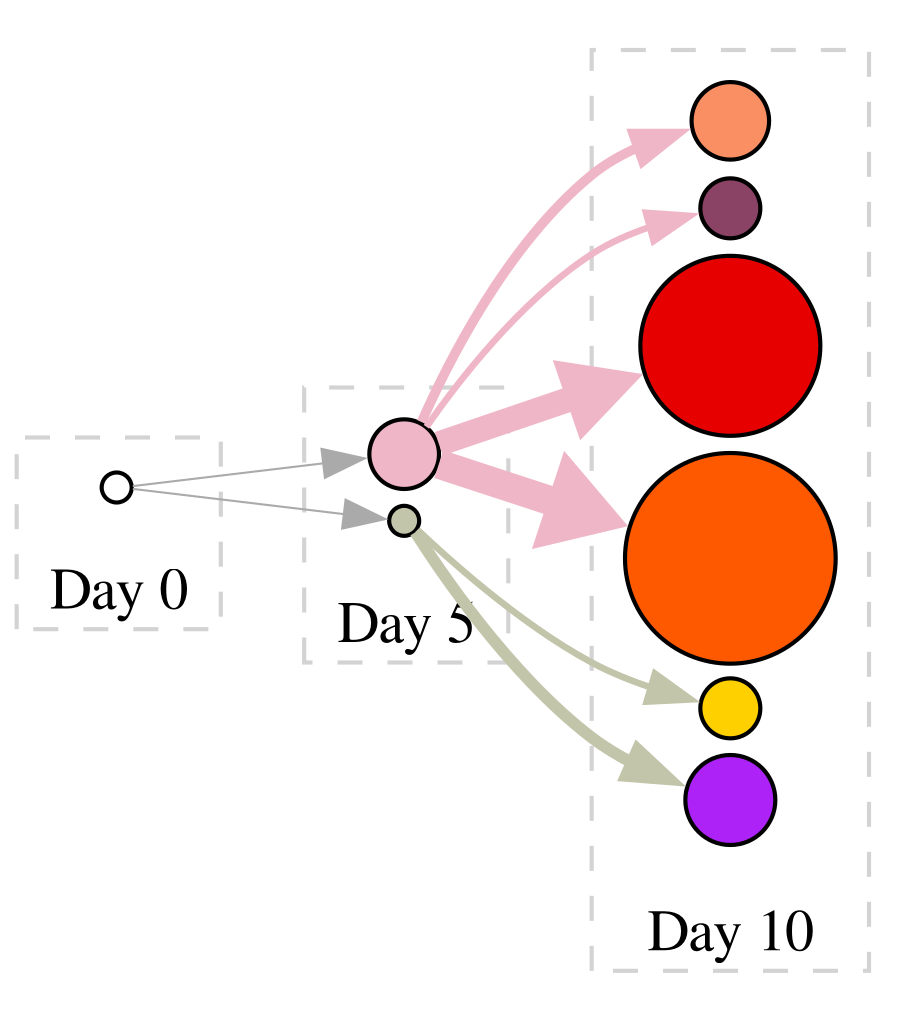

O20_III_6


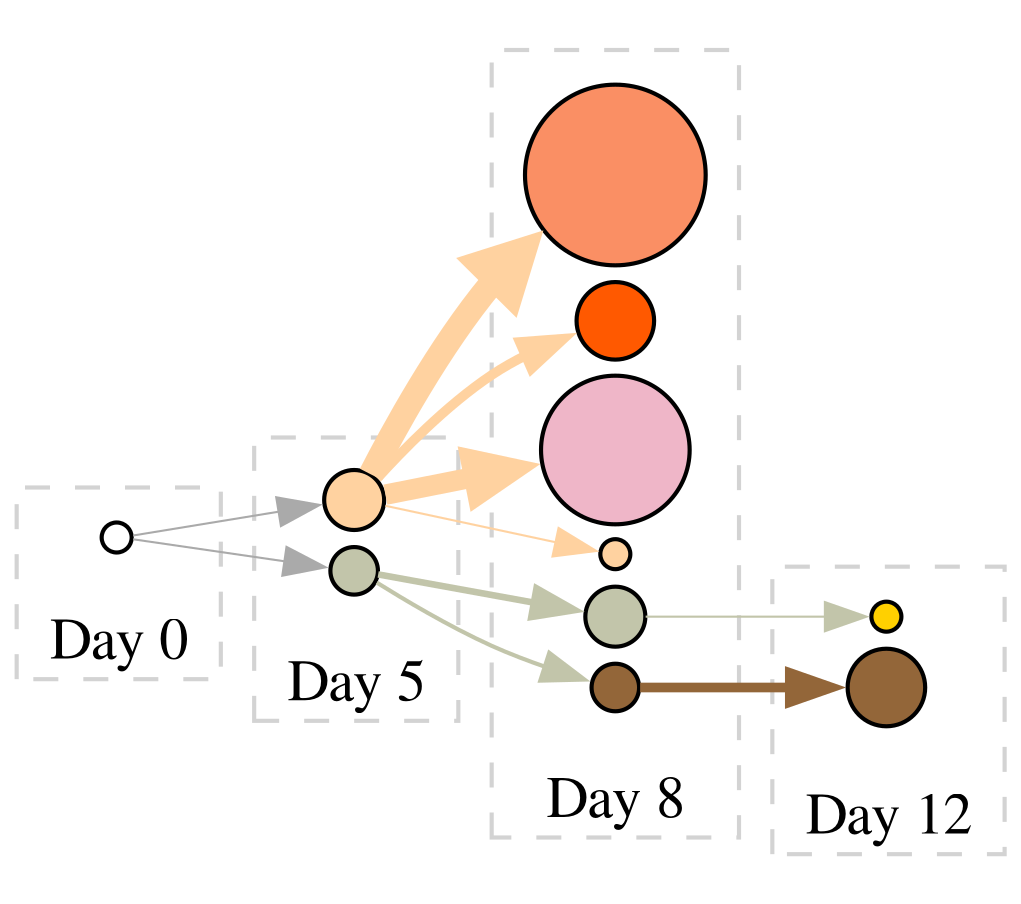

B9_I_7


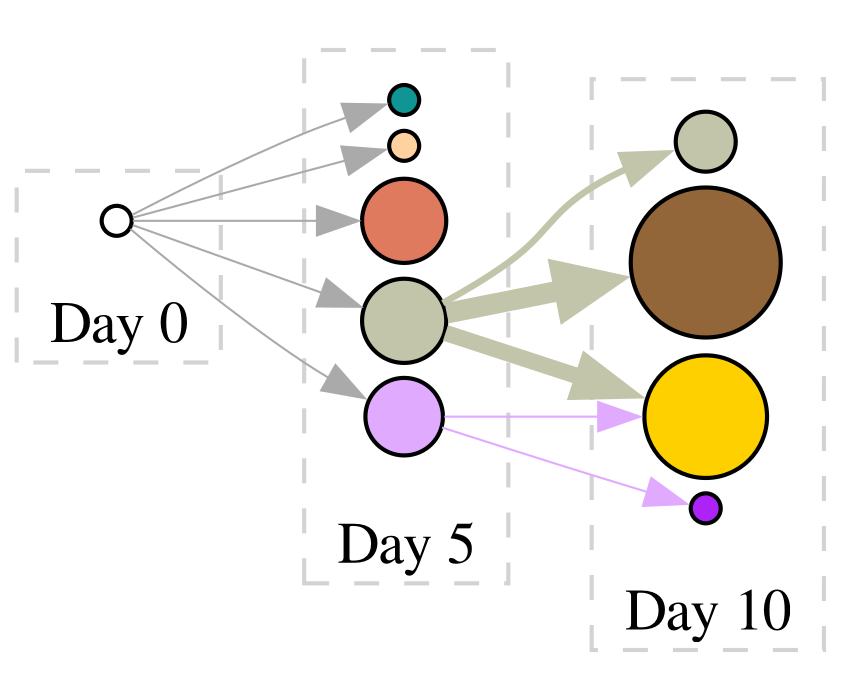

L7_II_7


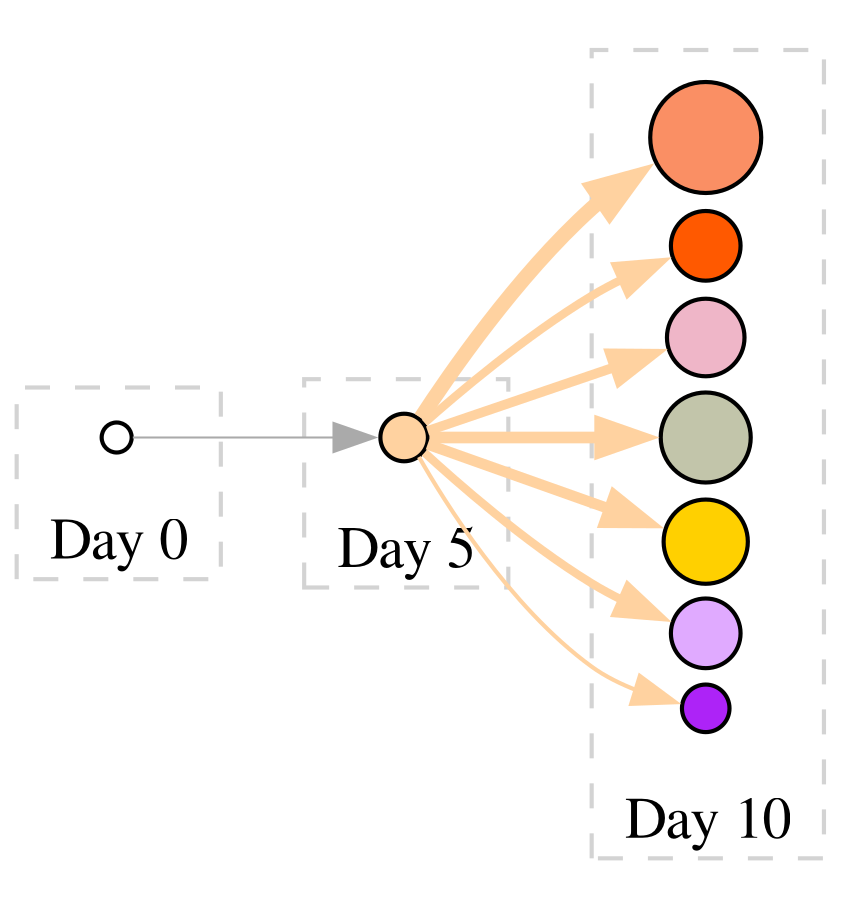

EWUKTS5W3EW0X8T4E9LRROPVZ_I_1


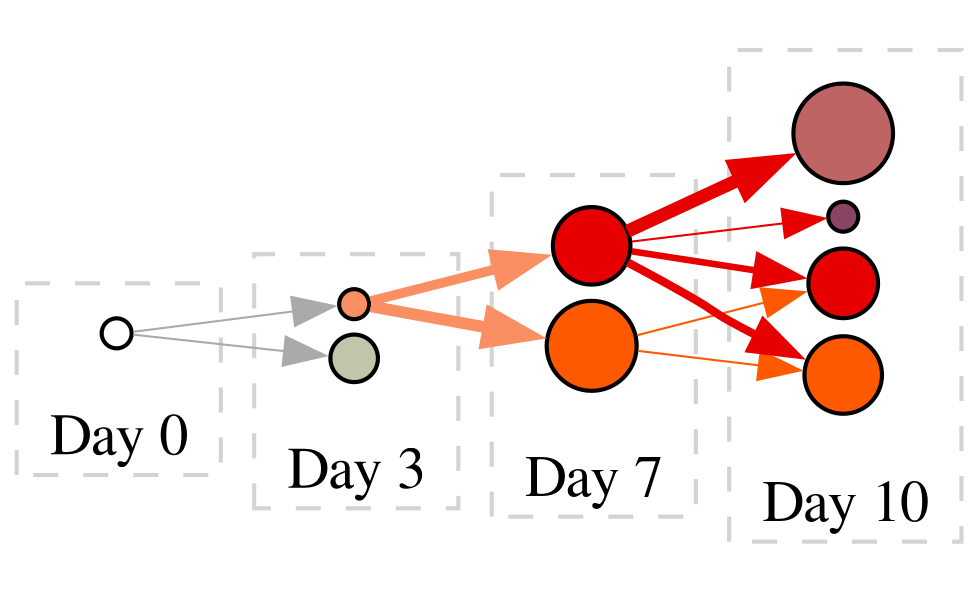

B9_III_6


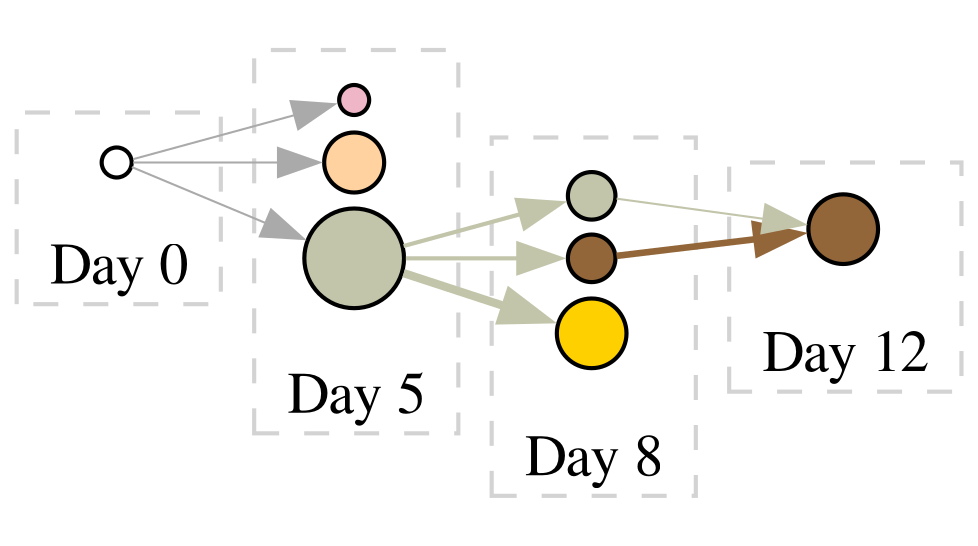

In [50]:
clones_to_show = ["EWUKTS5W3EW0X8T4E9LRROPVZ_I_1", "B9_III_6", "O20_III_6","L7_II_7","A9_I_7","B9_I_7", "O12_I_7"]

all_clones_list = CloneObject.convert_full_anndata_to_clones_objects(cells_with_clones[cells_with_clones.obs.clone_exp_id.isin(clones_to_show)], ordered_cell_types = [i for i in cell_type_colors.keys() if i not in ["doublets"]])
for clone_sample in all_clones_list:
    print(clone_sample.clone_exp_id)
    clone_sample.make_trajectory_graph(cell_type_colors, min_node_size = 0.1, max_edge_penwidth=10, add_first_day=True,
                                    fig_size=(8,8), nodesep="0.05", ranksep=str(1 / len(clone_sample.sample_day_as_int)),
                                    output_folder="./output", output_file="S2D_clones_schematic_%s" %clone_sample.clone_exp_id)
    clone_sample.make_trajectory_graph(cell_type_colors, min_node_size = 0.1, max_edge_penwidth=10, add_first_day=True,
                                    fig_size=(8,8), nodesep="0.05", ranksep=str(1 / len(clone_sample.sample_day_as_int)),
                                    )

clone_sample.make_node_size_legend(min_node_size=0.1, output_folder="./output", output_file="S2D_clones_schematic_legend")
clone_sample.make_node_size_legend(min_node_size=0.1)

## General data

In [110]:
print("Overall we have %d cells in clones with at least 2 cells" % sum(cells_with_clones_info.obs.clone_exp_id.isin(cells_with_clones_info.obs.groupby("clone_exp_id").size()[cells_with_clones_info.obs.groupby("clone_exp_id").size() >1].index)))
print("Which is %.2f percent of all cells" % (sum(cells_with_clones_info.obs.clone_exp_id.isin(cells_with_clones_info.obs.groupby("clone_exp_id").size()[cells_with_clones_info.obs.groupby("clone_exp_id").size() >1].index)) / cells_ad.shape[0] * 100))
print("An in %d clones" % sum(cells_with_clones_info.obs.groupby("clone_exp_id").size() >1))

Overall we have 44361 cells in clones with at least 2 cells
Which is 65.88 percent of all cells
An in 3844 clones


/tmp/ipykernel_931703/914941305.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/914941305.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/914941305.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/914941305.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=F

In [112]:
valid_clones_cells = cells_with_clones_info[cells_with_clones_info.obs.clone_exp_id.isin(cells_with_clones_info.obs.groupby("clone_exp_id").size()[cells_with_clones_info.obs.groupby("clone_exp_id").size() >1].index)]
valid_clones_with_two_timepoint_cells = valid_clones_cells[valid_clones_cells.obs.clone_exp_id.isin(valid_clones_cells.obs.groupby(["clone_exp_id"]).sample_day_as_int.nunique()[valid_clones_cells.obs.groupby(["clone_exp_id"]).sample_day_as_int.nunique() > 1].index)]

print(valid_clones_with_two_timepoint_cells.shape[0])
print(valid_clones_with_two_timepoint_cells.shape[0] / cells_ad.shape[0] * 100)
print(len(valid_clones_with_two_timepoint_cells.obs.clone_exp_id.unique()))

36319
53.94017703320858
2188


/tmp/ipykernel_931703/697609961.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/697609961.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_931703/697609961.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [43]:
cells_with_clonal_data_at_two_timepoints = mc.ut.slice(cells_with_clones, obs=cells_with_clones.obs.clone_exp_id.isin(cells_with_clones.obs.groupby(["clone_exp_id"]).sample_day_as_int.nunique()[cells_with_clones.obs.groupby(["clone_exp_id"]).sample_day_as_int.nunique() > 1].index))

/tmp/ipykernel_931703/305078066.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [44]:
cells_with_clonal_data_at_two_timepoints.obs.groupby(["condition"]).agg({'clone_exp_id': pd.Series.nunique, "cell_type": 'count'}).loc[media_list]

/tmp/ipykernel_931703/3462067531.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,clone_exp_id,cell_type
condition,,
I,878,17058
II,208,3058
III,360,9053
IV,124,2010


In [113]:
from scipy.stats import chisquare
condition_1_cells = cells_with_clones[cells_with_clones.obs.condition == "I"]
condition_1_cells_clones = condition_1_cells.obs.groupby(["clone_exp_id", "top_level_cell_type"], observed=True).size().unstack(fill_value=0)
only_ery_clones = sum(condition_1_cells_clones["Ery"] == condition_1_cells_clones.sum(axis=1))
chisquare([only_ery_clones, condition_1_cells_clones.shape[0] - only_ery_clones])

Power_divergenceResult(statistic=139.94708994708995, pvalue=2.733908429659849e-32)

In [114]:
from scipy.stats import fisher_exact, chi2_contingency

# Example: define early vs late
df = condition_1_cells.obs
early = df[df["sample_day_bin"] == "Early"]
mid = df[df["sample_day_bin"] == "Mid"]
late = df[df["sample_day_bin"] == "Late"]

sample_day_bin
Early     2566
Late     10383
Mid       7815
dtype: int64

In [130]:
number_of_cells_per_day_bin = condition_1_cells.obs.groupby(["sample_day_bin", "top_level_cell_type"]).size().unstack() 
number_of_cells_per_day_bin.div(number_of_cells_per_day_bin.sum(axis=1),axis=0)

/tmp/ipykernel_931703/2835651476.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



top_level_cell_type,BEMP,BEP,Basophils,Eosinophil,Ery,GMP,MEBEMP,MEP,MK,Mast,Monocyte,Neutrophils
sample_day_bin,,,,,,,,,,,,
Early,0.027670,0.110288,0.028839,0.009353,0.418940,0.001949,0.035853,0.262666,0.016368,0.087295,0.000000,0.000779
Late,0.000000,0.001059,0.009824,0.006645,0.967254,0.000096,0.000193,0.003082,0.000482,0.010498,0.000867,0.000000
Mid,0.000128,0.001024,0.002559,0.001408,0.968394,0.000384,0.000384,0.011772,0.009213,0.004607,0.000000,0.000128


In [47]:
# Count Ery vs non-Ery
table = pd.DataFrame({
    "Ery": [sum(early["top_level_cell_type"] == "Ery"), sum(mid["top_level_cell_type"] == "Ery")],
    "non_Ery": [sum(early["top_level_cell_type"] != "Ery"), sum(mid["top_level_cell_type"] != "Ery")]
}, index=["Early", "Mid"])

oddsratio, p_value = fisher_exact(table)  # use chi2_contingency(table) if counts large
print(table)
print("Fisher exact p-value:", p_value)

# Count Ery vs non-Ery
table = pd.DataFrame({
    "Ery": [sum(mid["top_level_cell_type"] == "Ery"), sum(late["top_level_cell_type"] == "Ery")],
    "non_Ery": [sum(mid["top_level_cell_type"] != "Ery"), sum(late["top_level_cell_type"] != "Ery")]
}, index=["Mid", "Late"])

oddsratio, p_value = fisher_exact(table)  # use chi2_contingency(table) if counts large
print(table)
print("Fisher exact p-value:", p_value)

# Count Ery vs non-Ery
table = pd.DataFrame({
    "Ery": [sum(early["top_level_cell_type"] == "Ery"), sum(late["top_level_cell_type"] == "Ery")],
    "non_Ery": [sum(early["top_level_cell_type"] != "Ery"), sum(late["top_level_cell_type"] != "Ery")]
}, index=["Early", "Late"])

oddsratio, p_value = fisher_exact(table)  # use chi2_contingency(table) if counts large
print(table)
print("Fisher exact p-value:", p_value)

# now print percentage of ery per time point
percent_ery = table["Ery"] / (table["Ery"] + table["non_Ery"]) * 100
print(percent_ery)

        Ery  non_Ery
Early  1075     1491
Mid    7568      247
Fisher exact p-value: 0.0
        Ery  non_Ery
Mid    7568      247
Late  10043      340
Fisher exact p-value: 0.6719914961489243
         Ery  non_Ery
Early   1075     1491
Late   10043      340
Fisher exact p-value: 0.0
Early    41.893998
Late     96.725417
dtype: float64


In [51]:
condition_2_cells = cells_with_clones[cells_with_clones.obs.condition =="I"]
condition_2_types_by_clone = condition_2_cells.obs.groupby(["clone_exp_id","top_level_cell_type"], observed=True).size().unstack()
print("Percent of clones with Ery cell types in media I: %.2f" % (sum(condition_2_types_by_clone[['Ery']].sum(axis=1) !=0) / condition_2_types_by_clone.shape[0] * 100))

Percent of clones with Ery cell types in media I: 87.04


In [48]:
condition_2_cells = cells_with_clones[cells_with_clones.obs.condition =="II"]
condition_2_types_by_clone = condition_2_cells.obs.groupby(["clone_exp_id","top_level_cell_type"], observed=True).size().unstack()
print("Percent of clones with BEMP cell types in media II: %.2f" % (sum(condition_2_types_by_clone[['BEMP', 'BEP', 'Basophils', 'Eosinophil', 'Mast']].sum(axis=1) !=0) / condition_2_types_by_clone.shape[0] * 100))

print("Percent of clones with GMP cell types in media II: %.2f" % (sum(condition_2_types_by_clone[['GMP', 'Monocyte', 'Neutrophils']].sum(axis=1) !=0) / condition_2_types_by_clone.shape[0] * 100))


Percent of clones with BEMP cell types in media II: 85.52
Percent of clones with GMP cell types in media II: 3.10


In [62]:
condition_2_cells = cells_with_clones[cells_with_clones.obs.condition =="III"]
condition_2_types_by_clone = condition_2_cells.obs.groupby(["clone_exp_id","top_level_cell_type"], observed=True).size().unstack()
print("Percent of clones with BEMP cell types in media III: %.2f" % (sum(condition_2_types_by_clone[['BEMP', 'BEP', 'Basophils', 'Eosinophil', 'Mast']].sum(axis=1) !=0) / condition_2_types_by_clone.shape[0] * 100))

print("Percent of clones with GMP cell types in media III: %.2f" % (sum(condition_2_types_by_clone[['GMP', 'Monocyte', 'Neutrophils']].sum(axis=1) !=0) / condition_2_types_by_clone.shape[0] * 100))
print("Percent of GMP cells in  media III: %.2f" % (condition_2_cells.obs['top_level_cell_type'].value_counts(normalize=True)[['GMP', 'Monocyte', 'Neutrophils']].sum() * 100))

Percent of clones with BEMP cell types in media III: 80.56
Percent of clones with GMP cell types in media III: 11.32
Percent of GMP cells in  media III: 37.98


In [63]:
condition_2_cells = cells_with_clones[cells_with_clones.obs.condition =="IV"]
condition_2_types_by_clone = condition_2_cells.obs.groupby(["clone_exp_id","top_level_cell_type"], observed=True).size().unstack()
print("Percent of clones with Eosinophils cell types in media IV: %.2f" % (sum(condition_2_types_by_clone[[ 'Eosinophil']].sum(axis=1) !=0) / condition_2_types_by_clone.shape[0] * 100))

Percent of clones with Eosinophils cell types in media IV: 27.40
